# Surrey Biome Pipeline — Phase 3b Walkthrough
### The Fraser Valley transect: does scale-free downscaling help where climate actually varies in space?

**Why this notebook exists.** Phase 3 tried to test one hypothesis over Surrey —
that scale-free downscaled ClimateBC (~375–750 m) forecasts corridor water stress
*better* than coarse grid climate. It came back **INCONCLUSIVE**, for a structural
reason: across 30 km of flat delta the between-corridor climate gradient is far
smaller than the interannual swing, and smaller still than the spatial variation
in the water stress being predicted. The predictor varied in *time*, the target in
*space* — orthogonal axes, nothing to measure (see `docs/RESOLUTION_TEST_FINDINGS.md`).

**Phase 3b changes exactly one thing: the study extent.** Same code, same
variables, same folds — but 300 BC VRI treed stands strung along a 100 km,
**4–1,920 m** south-of-Fraser elevation transect. Surrey stays the *application*
site; the transect is where the method question can actually be asked, because
here climate genuinely varies in space and can be meaningfully blurred.

This notebook runs the pipeline stage by stage and visualizes each one. It loads
cached artifacts from `data/interim/phase3b/`; set `REFETCH = True` to regenerate
from source (ClimateBC is rate-limited to ~50 calls/hour — a full transect pass is
~33 h — and the terrain step re-hits the Copernicus DEM).

**Kernel:** *Surrey Biome (venv)*.

In [1]:
# --- setup: paths resolve from the installed package, not the cwd ---
try:
    from src.pipeline import paths
except ModuleNotFoundError:
    import sys
    from pathlib import Path
    here = Path.cwd().resolve()
    root = next((p for p in (here, *here.parents) if (p / "pyproject.toml").exists()), None)
    if root is None:
        raise RuntimeError("Cannot locate the repo. Run `uv pip install -e .`.") from None
    sys.path.insert(0, str(root)); from src.pipeline import paths

import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import rioxarray

REPO, INT, PROC = paths.REPO, paths.INTERIM, paths.PROCESSED
P3B = INT / "phase3b"
FEATS   = PROC / "features_phase3b.parquet"
TERRAIN = P3B / "terrain_stands.parquet"
STANDS  = P3B / "transect_stands.gpkg"
REFETCH = False
YEARS = (2022, 2023, 2024, 2025)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})
print("repo root:", REPO, "| transect summers:", YEARS)
print("launched from:", __import__("os").getcwd())

repo root: /path/to/surrey-biome-pipeline | transect summers: (2022, 2023, 2024, 2025)
launched from: /path/to/surrey-biome-pipeline/notebooks


## Stage 1 — Predictors: ClimateBC across a real elevation gradient

The whole reason for the transect is visible here. ClimateBC is *scale-free*: it
keys its downscaling on each stand's own elevation, so effective resolution comes
from the DEM, not a fixed grid. Over Surrey elevation ran −1 to 116 m; here it
runs **4–1,920 m over 100 km**, so the summer climate moisture deficit (CMD)
varies strongly *between stands* — the spatial axis Surrey lacked. Note it also
swings hard *between years* (the 2024/2025 wet summers vs 2022/2023): keep that
temporal-vs-spatial split in mind, it returns in Stage 6.

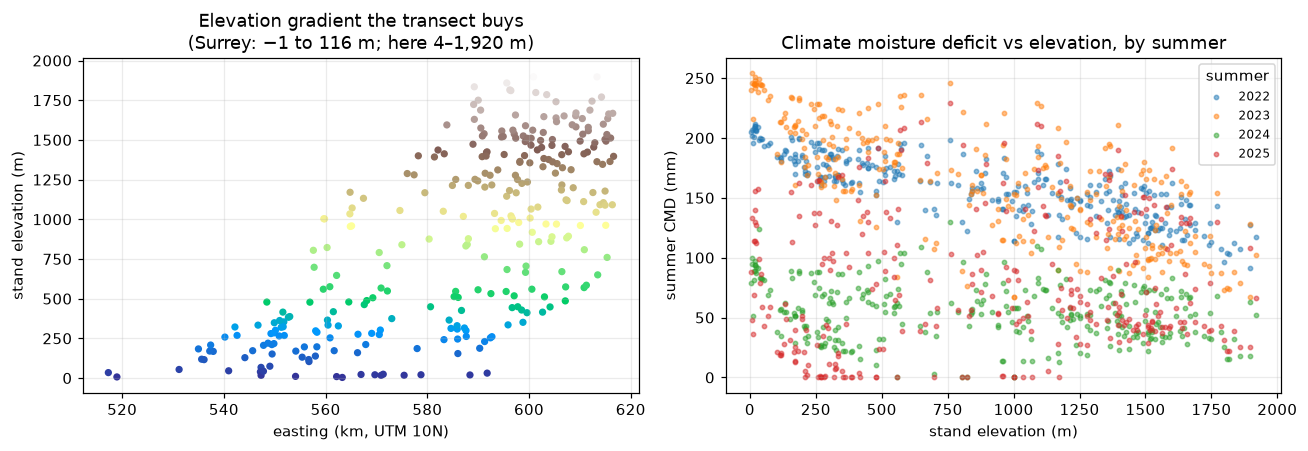

summer CMD_sm — spatial spread within a year vs swing between years:
  between-stand sd (2025):   55.8 mm
  between-year  sd (means):   55.2 mm


In [2]:
if REFETCH:   # long-running: ~50 calls/hour, resumable via the disk cache
    from src.pipeline import acquire_climate as ac
    ac.run(STANDS, P3B, years=YEARS, corridor_layer="stands_analysis")

df = pd.read_parquet(FEATS)
stand_elev = df.groupby("objectid").agg(elev=("elev_m", "first"),
                                        x_m=("x_m", "first")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(stand_elev["x_m"] / 1000, stand_elev["elev"], s=14, c=stand_elev["elev"],
                cmap="terrain")
axes[0].set(xlabel="easting (km, UTM 10N)", ylabel="stand elevation (m)",
            title="Elevation gradient the transect buys\n(Surrey: −1 to 116 m; here 4–1,920 m)")
for yr in YEARS:
    d = df[df["year"] == yr]
    axes[1].scatter(d["elev_m"], d["CMD_sm"], s=8, alpha=.5, label=str(yr))
axes[1].set(xlabel="stand elevation (m)", ylabel="summer CMD (mm)",
            title="Climate moisture deficit vs elevation, by summer")
axes[1].legend(title="summer", fontsize=8)
plt.tight_layout(); plt.show()

print("summer CMD_sm — spatial spread within a year vs swing between years:")
print(f"  between-stand sd (2025): {df[df.year==2025]['CMD_sm'].std():6.1f} mm")
print(f"  between-year  sd (means): {df.groupby('year')['CMD_sm'].mean().std():6.1f} mm")

## Stage 2 — Ground truth: the RS composites over the transect

The optical (Sentinel-2 NDVI/SWCI) and thermal (Landsat LST) summer composites are
built exactly as in Phase 3, over 2 MGRS tiles / ~2,840 km² — 7× Surrey's area.
Two things to confirm on the new extent: the Phase 2 BOA-offset bug does **not**
recur (the offset measures as 0 DN here), and the thin-corridor pixel problem is
gone — VRI stands are large, so `coverage_frac` is ~1.0 everywhere. The elevation
gradient already shows up in the *target-adjacent* thermal signal: LST spans tens
of °C between stands, against Surrey's ~3 °C.

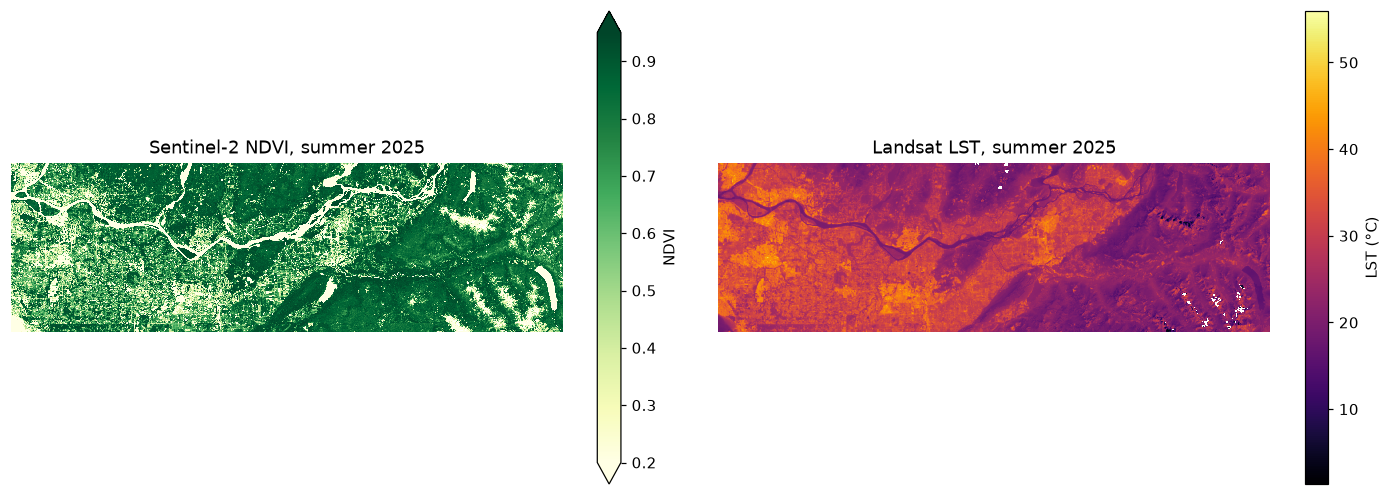

LST between-stand spread (2025): 16.1–38.8 °C  (sd 3.3)
stand pixel coverage: median 1.00, min 0.97  → no thin-corridor problem


In [3]:
opt = rioxarray.open_rasterio(P3B / "optical_2025.tif", masked=True)   # band 1 = NDVI
lst = rioxarray.open_rasterio(P3B / "lst_2025.tif", masked=True)       # band 1 = LST °C

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
opt.isel(band=0).plot.imshow(ax=axes[0], cmap="YlGn", vmin=0.2, vmax=0.95,
                             add_labels=False, cbar_kwargs={"label": "NDVI"})
axes[0].set_title("Sentinel-2 NDVI, summer 2025")
lst.isel(band=0).plot.imshow(ax=axes[1], cmap="inferno", add_labels=False,
                             cbar_kwargs={"label": "LST (°C)"})
axes[1].set_title("Landsat LST, summer 2025")
for a in axes: a.set_aspect("equal"); a.axis("off")
plt.tight_layout(); plt.show()

print(f"LST between-stand spread (2025): {df[df.year==2025]['lst_mean'].min():.1f}"
      f"–{df[df.year==2025]['lst_mean'].max():.1f} °C  "
      f"(sd {df[df.year==2025]['lst_mean'].std():.1f})")
print(f"stand pixel coverage: median {df['coverage_frac_ndvi'].median():.2f}, "
      f"min {df['coverage_frac_ndvi'].min():.2f}  → no thin-corridor problem")

## Stage 3 — The target: CDEI, and the axis it varies on

CDEI (Temperature-Vegetation Water Stress Index) is the Phase 1 target, unchanged.
The decisive contrast with Surrey is *which axis it varies on*. Over Surrey CDEI
was mostly **temporal** (4.1× between years vs between corridors), which is exactly
the axis the coarse-cell upscale leaves untouched — so Models A and B were near
identical. Here CDEI is overwhelmingly **spatial**: it varies ~120× more between
stands than between years. There is a real spatial pattern to predict. Whether the
*climate* gradient explains it is the question Stage 5–7 answer.

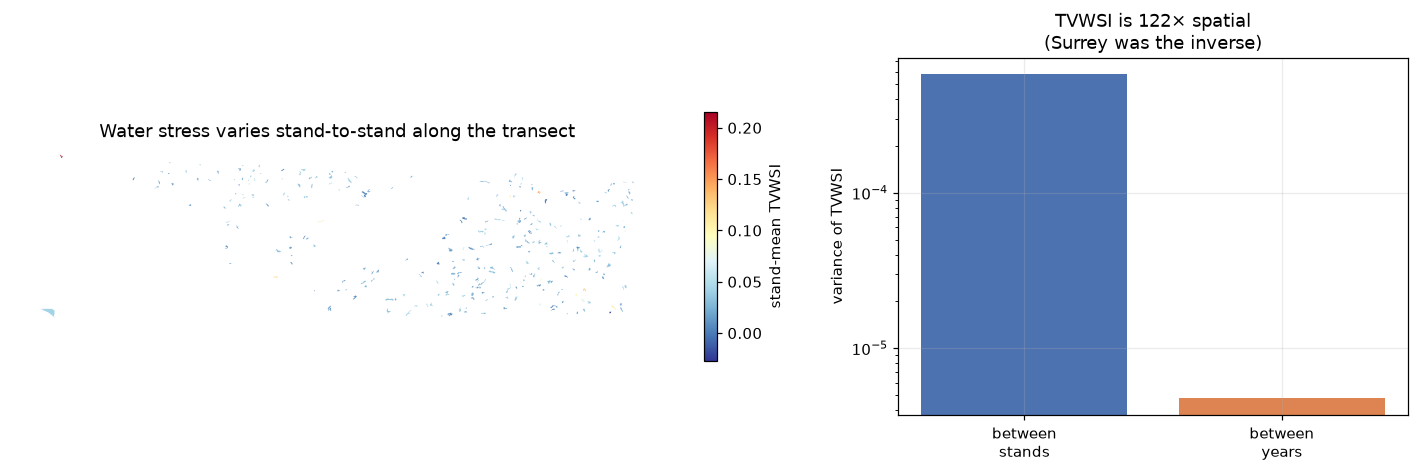

CDEI between-stand sd 0.0241  vs  between-year sd 0.0022


In [4]:
g = gpd.read_file(STANDS, layer="stands_analysis")[["objectid", "geometry"]].to_crs("EPSG:26910")
sm = df.groupby("objectid")["tvwsi"].mean().reset_index()
gm = g.merge(sm, on="objectid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.6, 1]})
gm.plot(column="tvwsi", cmap="RdYlBu_r", legend=True, ax=axes[0], markersize=18,
        legend_kwds={"label": "stand-mean CDEI", "shrink": .7})
axes[0].set_title("Water stress varies stand-to-stand along the transect")
axes[0].set_axis_off()

btwn_stand = df.groupby("objectid")["tvwsi"].mean().var()
btwn_year  = df.groupby("year")["tvwsi"].mean().var()
axes[1].bar(["between\nstands", "between\nyears"], [btwn_stand, btwn_year],
            color=["#4c72b0", "#dd8452"])
axes[1].set(ylabel="variance of CDEI", title=f"CDEI is {btwn_stand/btwn_year:.0f}× spatial\n(Surrey was the inverse)")
axes[1].set_yscale("log")
plt.tight_layout(); plt.show()
print(f"CDEI between-stand sd {np.sqrt(btwn_stand):.4f}  vs  between-year sd {np.sqrt(btwn_year):.4f}")

## Stage 4 — Assemble the ML table

`assemble.py` runs unchanged on the transect: zonal NDVI/SWCI/LST per stand ×
summer, the dry-edge fit, CDEI, and the climate-only predictor block (raw normals,
anomalies vs the 1961–1990 baseline, log-precip and Mahalanobis climate novelty).
Elevation is deliberately kept *out* of the climate predictors — it is the DEM
input ClimateBC keys on, so handing it to the model would let Model A win on
terrain rather than on climate. Result: 1,200 rows = 300 stands × 4 summers.

In [5]:
from src.pipeline import assemble
if REFETCH:
    assemble.run(STANDS, P3B, out=FEATS, years=YEARS, corridor_layer="stands_analysis",
                 climate_parquet=P3B / "corridor_climate.parquet")

clim = assemble.predictor_columns(df)["climate_only"]
print(f"panel: {len(df)} rows | {df['objectid'].nunique()} stands × {df['year'].nunique()} summers")
print(f"climate-only predictors ({len(clim)}): {', '.join(clim)}")
print("\nper-summer means:")
for yr, grp in df.groupby("year"):
    print(f"  {yr}  n={len(grp)}  tvwsi={grp['tvwsi'].mean():+.4f}  "
          f"ndvi={grp['ndvi_mean'].mean():.3f}  lst={grp['lst_mean'].mean():5.2f}°C  "
          f"CMD_sm={grp['CMD_sm'].mean():6.1f}")
df[["objectid", "year", "tvwsi", "CMD_sm", "Tmax_sm", "ndvi_mean", "lst_mean"]].head(4)

panel: 1200 rows | 300 stands × 4 summers
climate-only predictors (14): CMD_sm, CMD_sm_anom, DD18_sm, Eref_sm, Eref_sm_anom, PPT_sm, PPT_sm_anom, Rad_sm, Tmax_sm, Tmax_sm_anom, Tmin_sm, Tmin_sm_anom, logPPT_sm, novelty

per-summer means:
  2022  n=300  tvwsi=+0.0259  ndvi=0.831  lst=24.65°C  CMD_sm= 158.5
  2023  n=300  tvwsi=+0.0311  ndvi=0.821  lst=24.36°C  CMD_sm= 162.7
  2024  n=300  tvwsi=+0.0280  ndvi=0.826  lst=23.85°C  CMD_sm=  54.7
  2025  n=300  tvwsi=+0.0274  ndvi=0.828  lst=22.11°C  CMD_sm=  78.0


,objectid,year,tvwsi,CMD_sm,Tmax_sm,ndvi_mean,lst_mean
0,1,2022,0.033647,198.0,23.3,0.793425,28.608619
1,2,2022,0.010618,208.0,24.9,0.888974,27.278736
2,3,2022,0.035364,153.0,19.8,0.829007,21.374277
3,4,2022,0.040090,154.0,19.2,0.865777,22.921207


## Stage 5 — The core experiment: Model A vs Model B, swept across grid resolution

* **Model A (scale-free ~1 km)** — ClimateBC at each stand's own location and elevation.
* **Model B (coarse)** — *the same variables*, averaged within a square grid cell
  per year; each stand then takes its cell's value. Averaging within (cell, year)
  leaves the temporal signal intact, so only *spatial* detail is destroyed.

Validation is repeated spatially-blocked, corridor-grouped leave-one-block-out CV,
identical to Phase 3. **The upscaling diagnostic must be read first:** if coarsening
removes almost no spatial variance, A and B are the same model and any result is
uninformative. That was Surrey's fate (12% at 4 km). Here we *sweep* the cell size
to find where the blur becomes real — and watch the verdict change with it.

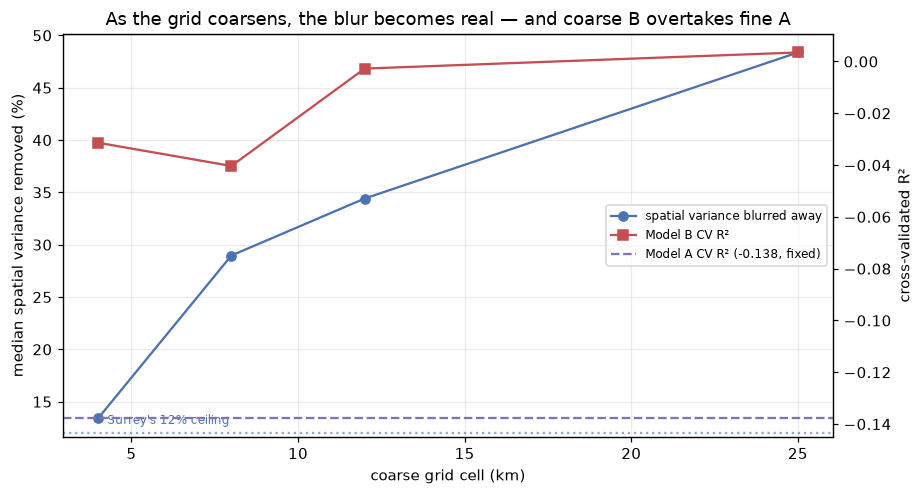

,cell_km,var_removed,r2_b
0,4.0,0.134,-0.031
1,8.0,0.290,-0.040
2,12.0,0.344,-0.003
3,25.0,0.484,0.003


In [6]:
from src.pipeline import experiment as ex

# Model A is fixed; only Model B's cell size changes. Sweep it.
feats = ex.predictor_columns(df)["climate_only"]
folds_a, _ = ex.blocked_cv(df, feats, n_blocks=5, n_repeats=5)
r2_a = folds_a["r2"].mean()

sweep = []
for cell in (4000, 8000, 12000, 25000):
    diag = ex.upscaling_diagnostics(df, feats, cell_m=cell)
    dfb = ex.upscale(df, feats, cell_m=cell)
    folds_b, _ = ex.blocked_cv(dfb, feats, n_blocks=5, n_repeats=5)
    sweep.append({"cell_km": cell / 1000, "var_removed": diag["var_removed_frac"].median(),
                  "r2_b": folds_b["r2"].mean()})
sweep = pd.DataFrame(sweep)

fig, ax1 = plt.subplots(figsize=(8.5, 4.6))
ax1.plot(sweep["cell_km"], sweep["var_removed"] * 100, "o-", color="#4c72b0",
         label="spatial variance blurred away")
ax1.axhline(12, ls=":", color="#4c72b0", alpha=.6)
ax1.annotate("Surrey's 12% ceiling", (4, 12), textcoords="offset points", xytext=(6, 6),
             fontsize=8, color="#4c72b0")
ax1.set(xlabel="coarse grid cell (km)", ylabel="median spatial variance removed (%)")
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(sweep["cell_km"], sweep["r2_b"], "s-", color="#c44e52", label="Model B CV R²")
ax2.axhline(r2_a, ls="--", color="#8172b3", label=f"Model A CV R² ({r2_a:+.3f}, fixed)")
ax2.set_ylabel("cross-validated R²")
ax1.set_title("As the grid coarsens, the blur becomes real — and coarse B overtakes fine A")
lines = ax1.get_lines()[:1] + ax2.get_lines()
ax2.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="center right")
plt.tight_layout(); plt.show()
sweep.round(3)

### The verdict at a realistic regional-grid resolution (25 km)

25 km is a faithful stand-in for the grid the hypothesis set out to beat. At that
cell the median predictor loses ~half its spatial variance (leading ones two-thirds)
— a genuine A-vs-B contrast — and the full experiment returns its verdict with the
paired confidence interval, forward temporal holdout, and Model-A importances.

In [7]:
res = ex.run(FEATS, kind="rf", cell_m=25000.0, n_blocks=5, n_repeats=5)
fa, fb = res["folds_a"], res["folds_b"]
print(f"Model A (scale-free ~1 km): RMSE {fa.rmse.mean():.5f}  R2 {fa.r2.mean():+.3f}")
print(f"Model B (coarse 25 km)    : RMSE {fb.rmse.mean():.5f}  R2 {fb.r2.mean():+.3f}")
d = res["diffs"]["rmse"]; dr = res["diffs"]["r2"]
print(f"\npaired A−B rmse: {d['mean_diff']:+.5f}  95% CI [{d['ci_lo']:+.5f}, {d['ci_hi']:+.5f}]")
print(f"paired A−B r2  : {dr['mean_diff']:+.5f}  95% CI [{dr['ci_lo']:+.5f}, {dr['ci_hi']:+.5f}]")
print(f"\nVERDICT: {res['verdict']}")
print(res["verdict_reason"])
ta, tb = res["temporal_a"], res["temporal_b"]
if ta.get("n_test"):
    print(f"\nforward holdout (train <{ta['test_year']}, test {ta['test_year']}, n={ta['n_test']}):")
    print(f"  A RMSE {ta['rmse']:.5f} R2 {ta['r2']:+.3f}  |  B RMSE {tb['rmse']:.5f} R2 {tb['r2']:+.3f}")
    print("  (note: A's slim edge is *temporal*; spatially, coarse B wins — see the CI above)")

Model A (scale-free ~1 km): RMSE 0.02565  R2 -0.138
Model B (coarse 25 km)    : RMSE 0.02472  R2 +0.003

paired A−B rmse: +0.00093  95% CI [+0.00021, +0.00170]
paired A−B r2  : -0.14127  95% CI [-0.25660, -0.04149]

VERDICT: FALSIFIED
Model B is significantly *better* than Model A. The extra spatial detail is not just unhelpful, it is actively hurting — most likely noise the coarse average smooths away.

forward holdout (train <2025, test 2025, n=300):
  A RMSE 0.02415 R2 +0.061  |  B RMSE 0.02579 R2 -0.070
  (note: A's slim edge is *temporal*; spatially, coarse B wins — see the CI above)


## Stage 6 — Why no climate resolution has spatial skill

Both preconditions of a decisive A-vs-B test must hold: a real blur (Stage 5 —
now satisfied) **and** a model with spatial skill. The second still fails: Model A's
CV R² is negative. Unlike Surrey this is *not* orthogonal axes — the target varies
strongly in space (Stage 3). The problem is that the climate gradient and the water-
stress pattern, though both spatial, are **orthogonal to each other**: stand-mean
CDEI is nearly uncorrelated with CMD, Tmax, Eref or elevation. The macroclimate
gradient is simply not what organizes water stress between these stands.

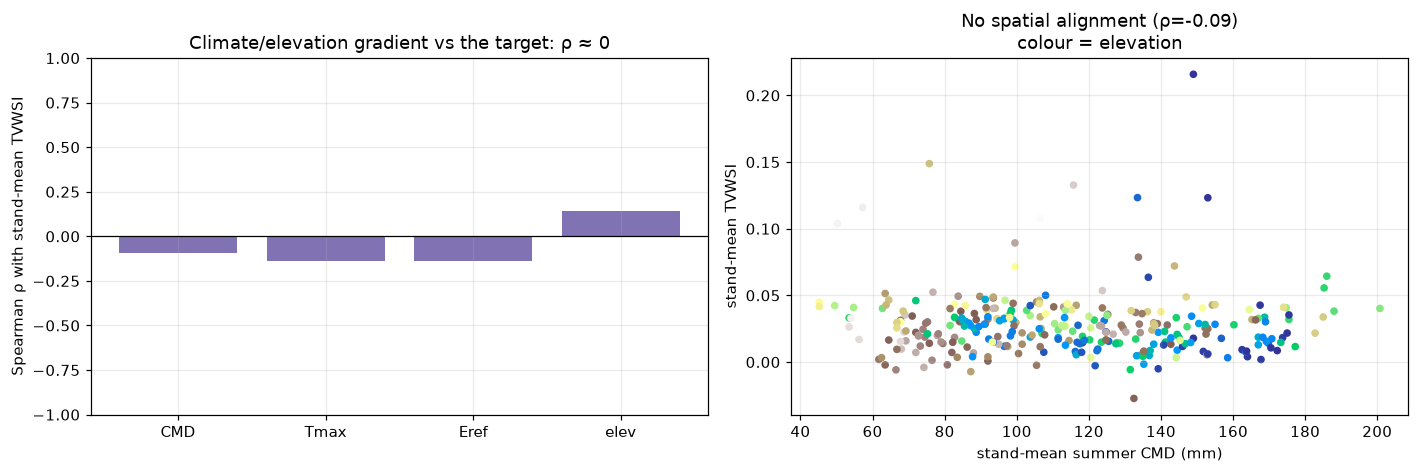

CDEI varies 122× more between stands than between years,
yet is ~uncorrelated with the climate gradient — so climate resolution has nothing to grip.


In [8]:
from src.pipeline import explain
rx = explain.run(FEATS, TERRAIN, STANDS, "stands_analysis")   # loads cached terrain
o = rx["orthogonality"]; smn = o["stand_means"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].bar(list(o["spearman"].keys()), list(o["spearman"].values()), color="#8172b3")
axes[0].axhline(0, color="k", lw=.8)
axes[0].set(ylim=(-1, 1), ylabel="Spearman ρ with stand-mean CDEI",
            title="Climate/elevation gradient vs the target: ρ ≈ 0")
axes[1].scatter(smn["CMD"], smn["tvwsi"], s=16, c=smn["elev"], cmap="terrain")
axes[1].set(xlabel="stand-mean summer CMD (mm)", ylabel="stand-mean CDEI",
            title=f"No spatial alignment (ρ={o['spearman']['CMD']:+.2f})\ncolour = elevation")
plt.tight_layout(); plt.show()
print(f"CDEI varies {o['spatial_temporal_ratio']:.0f}× more between stands than between years,")
print("yet is ~uncorrelated with the climate gradient — so climate resolution has nothing to grip.")

## Stage 7 — Then what *does* drive between-stand water stress?

The follow-up model (`explain.py`) compares predictor families under the same
blocked CV. RS bands (NDVI/SWCI/LST) are excluded — CDEI is built from them, so
they would be circular. Terrain here is slope, aspect (as northness/eastness vector
components, the circular-safe polygon average), within-stand ruggedness and
elevation from the Copernicus GLO-30 DEM; structure is the VRI stand attributes.

Only **terrain + stand structure** crosses into positive skill, and adding climate
on top makes it *worse* — confirming the climate gradient is noise for this target.
The signal is weak (R² ≈ 0.03), and the leading drivers are **local**: leading
species, stand size, and aspect. Two honesty flags travel with this: most variance
stays unexplained, and species/broadleaf ranking high hints that CDEI partly
encodes canopy *type* (broadleaf vs conifer occupy different NDVI–SWCI–LST space)
rather than water stress alone.

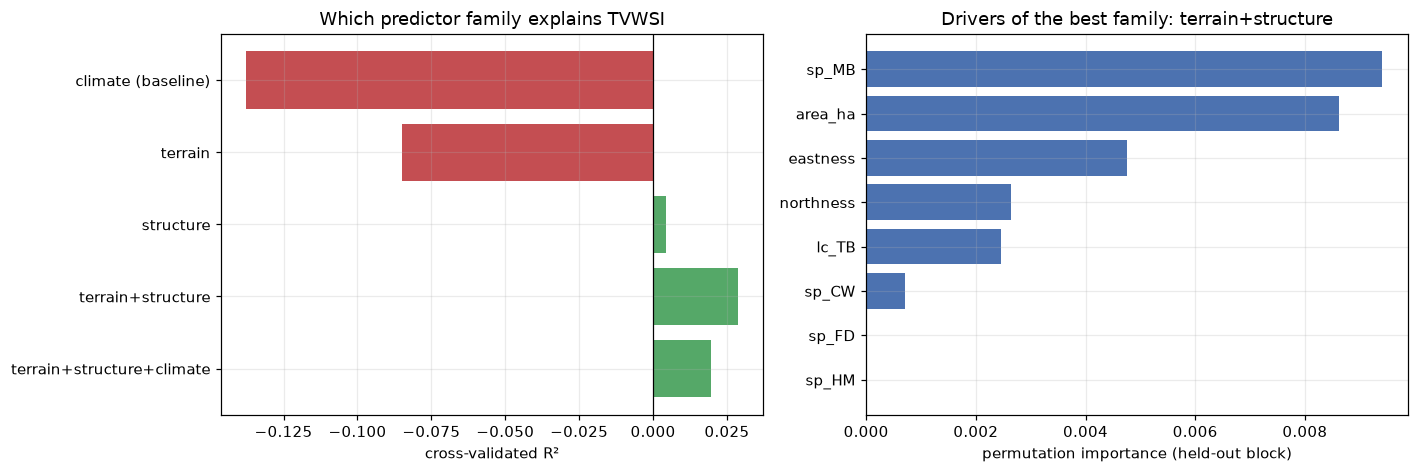

                           n_features   rmse     r2  frac_folds_positive
family                                                                  
climate (baseline)                 14  0.026 -0.138                 0.40
terrain                             5  0.025 -0.085                 0.44
structure                          24  0.025  0.004                 0.68
terrain+structure                  29  0.024  0.029                 0.80
terrain+structure+climate          43  0.024  0.020                 0.60


In [9]:
tab = rx["table"].set_index("family")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
colors = ["#c44e52" if v < 0 else "#55a868" for v in tab["r2"]]
axes[0].barh(tab.index[::-1], tab["r2"][::-1], color=colors[::-1])
axes[0].axvline(0, color="k", lw=.8)
axes[0].set(xlabel="cross-validated R²", title="Which predictor family explains CDEI")
imp = rx["importance"].head(8)[::-1]
axes[1].barh(imp["feature"], imp["importance"], color="#4c72b0")
axes[1].set(xlabel="permutation importance (held-out block)",
            title=f"Drivers of the best family: {rx['best']}")
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

## Verdict — and what it means for Surrey

**The transect did its job.** Surrey couldn't test the hypothesis at all; the
transect can, and it returns a clear direction:

> Where a real spatial climate gradient exists, scale-free downscaled climate still
> does **not** beat coarse grid climate for corridor/stand water stress — at a
> realistic 25 km grid the coarse model is *significantly better* (paired CI
> excludes zero). Water stress at this scale is governed by **local terrain aspect
> and stand composition**, not the macroclimate gradient that downscaling resolves.

Two independent walls, both now diagnosed rather than assumed: the climate gradient
does not align with the target (Stage 6), and the fine-scale detail is anti-
informative once you blur enough to tell A from B (Stage 5). For the Surrey Green
Infrastructure application this sharpens the payoff: **the monitoring asset is
*which corridors are stressed and why* — and the "why" is local (aspect, canopy
composition, stand structure), not something a finer climate product would surface.**
Climate resolution is the wrong lever; the RS-derived stress index plus local
stand/terrain context are the right ones. Full write-up: `docs/RESOLUTION_TEST_FINDINGS.md`.

In [10]:
print("=" * 74)
print(f"PHASE 3b VERDICT: {res['verdict']}  (coarse 25 km grid)")
print("=" * 74)
print(f"Model A (scale-free) R²  {res['folds_a'].r2.mean():+.3f}   "
      f"Model B (coarse 25 km) R²  {res['folds_b'].r2.mean():+.3f}")
print(f"best explanatory family : {rx['best']}  (CV R² "
      f"{rx['table'].set_index('family').loc[rx['best'],'r2']:+.3f}, weak but positive)")
print(f"top local drivers       : "
      f"{', '.join(rx['importance'].head(4)['feature'])}")
print(f"panel                   : {df['objectid'].nunique()} stands × "
      f"{df['year'].nunique()} summers = {len(df)} rows over a 4–1,920 m transect")

PHASE 3b VERDICT: FALSIFIED  (coarse 25 km grid)
Model A (scale-free) R²  -0.138   Model B (coarse 25 km) R²  +0.003
best explanatory family : terrain+structure  (CV R² +0.029, weak but positive)
top local drivers       : sp_MB, area_ha, eastness, northness
panel                   : 300 stands × 4 summers = 1200 rows over a 4–1,920 m transect
